# Import the necessary modules

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.neighbors import NearestNeighbors

# Load the pre-processed data

In [2]:
h_all = pd.read_csv('./embeddings.csv.tar.gz')

h_all_features = h_all[[col for col in h_all.columns if col != 'Anomaly']]
mask = h_all['Anomaly'] == 1.0

# Run KNN

In [3]:
def get_KNN_cosine_dist(k, h):
    neighbors = NearestNeighbors(n_neighbors=k, metric="cosine").fit(h)
    distances, indices = neighbors.kneighbors(h)
    distances = pd.DataFrame(distances)
    k_dist = distances.max(axis=1)
    k_dist = pd.DataFrame(k_dist)
    k_dist.columns = ["Distance"]
    k_dist["Position"] = k_dist.index
    return k_dist


def plot_KNN(k_dist, mask):
    ratio_anomaly = k_dist[mask]
    plt.figure(figsize=(8, 5))
    sns.histplot(data=k_dist['Distance'], alpha=1, linewidth=0.3)
    for d in ratio_anomaly['Distance']:
        plt.text(d, 12, '*', fontsize=12, color="red")
    plt.axvline(x=k_dist["Distance"].quantile(0.90), color="black",     linestyle="--", alpha=1, label="p90", linewidth=0.7)
    plt.axvline(x=k_dist["Distance"].quantile(0.95), color="limegreen", linestyle="--", alpha=1, label="p95", linewidth=0.7)
    plt.axvline(x=k_dist["Distance"].quantile(0.99), color="deeppink",  linestyle="--", alpha=1, label="p99", linewidth=0.7)
    plt.title("Nearest Neighbors K="+str(k))
    plt.xlabel("K-Neigbor Dissimilarity")
    plt.ylabel("Frequency")
    plt.legend()
    ax = plt.gca()
    ax.set_facecolor('gainsboro')
    plt.show()

In [4]:
k_values = [2, 5, 10, 15, 20, 30]
colors = ['royalblue', 'orange', 'red', 'black', 'hotpink', 'green']
dists = {k: get_KNN_cosine_dist(k, h_all_features) for k in k_values}

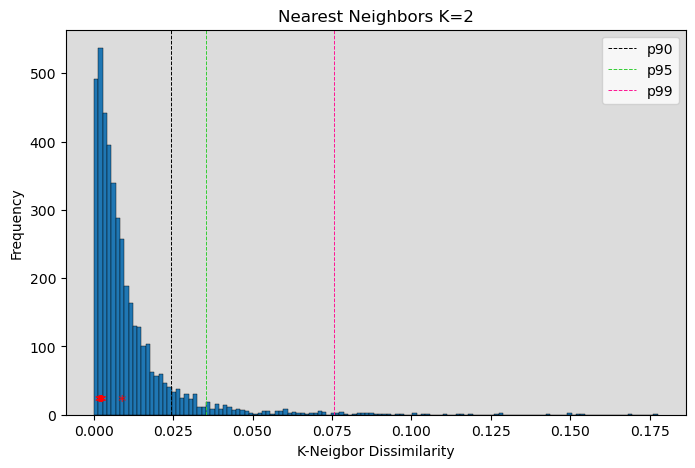

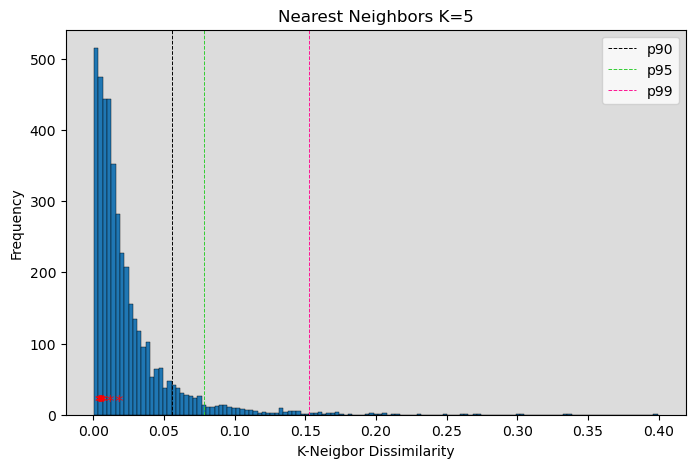

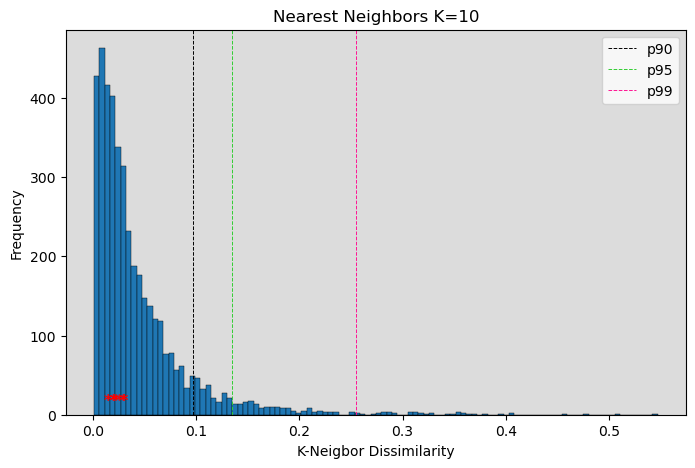

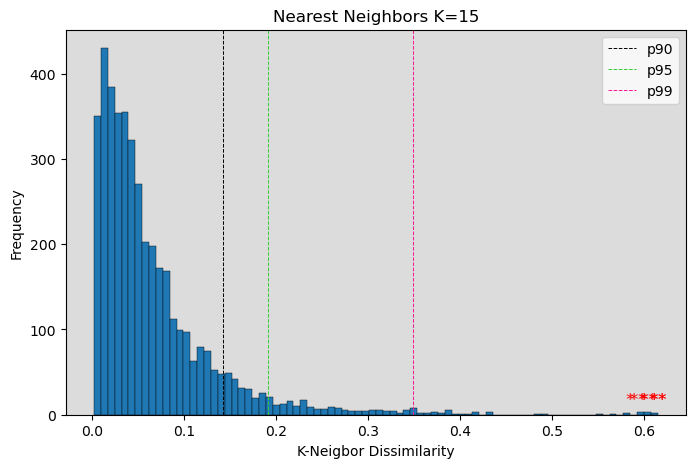

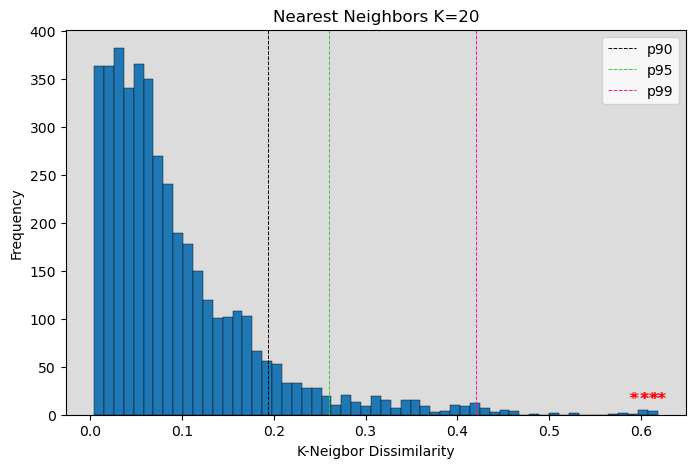

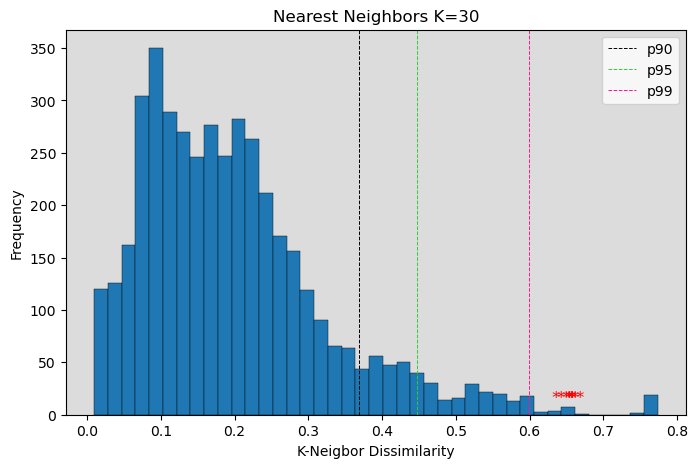

In [5]:
for k in k_values:
    plot_KNN(dists[k], mask)

# Plot dissimilarity

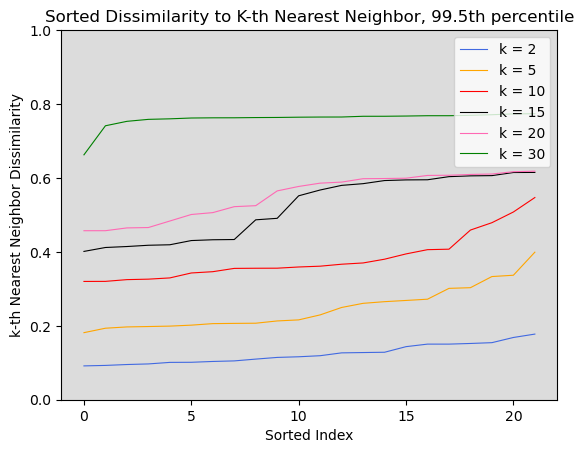

In [6]:
def plot_dissimilarity(k_values, colors, percentile):
    for k, color in zip(k_values, colors):
        dist = np.sort(dists[k]['Distance'])
        threshold = np.quantile(dist, percentile)
        subset = dist[dist >= threshold]
        plt.plot(range(len(subset)), subset, label=f'k = {k}', color=color, linewidth=0.8)
    ax = plt.gca()
    ax.set_facecolor('gainsboro')
    plt.legend()
    plt.ylim([0, 1])
    plt.title(f"Sorted Dissimilarity to K-th Nearest Neighbor, {100*percentile}th percentile")
    plt.xlabel("Sorted Index")
    plt.ylabel('k-th Nearest Neighbor Dissimilarity')
    plt.show()

plot_dissimilarity(k_values, colors, 0.995)